# Wi2SAR Figure 11 Direction and Score Recompute

Figure 11 (a)-(g) is the core result reproduced in this notebook. It summarizes the direction-finding performance across scenes, target placements, incident angles, drone speed, drone-target distance, average RSS, and the ArrayTrack comparison. Figure 11 reports `N=13,671` samples; this notebook uses exactly that sample set.

![Figure 11 reference from the Wi2SAR paper](frontend/reference_images/fig11_direction_finding_reference.png)

This notebook has one purpose: show how the Figure 11 score is obtained from the data released with the AE package.

The released columns `azimuth` and `elevation` are the **estimated direction** recorded online by the drone during flight trials. The online direction finding configuration **evolved** across experiment stages. For example, part of the data (in Year 2024) used `-92 dBm` as the missing-RSSI noise floor, while the later (in Year 2025) configuration uses `-127 dBm` (apparently much more reasonable). Therefore, the direction finding results are not bit-by-bit reproduced, but actually improved using (Year 2025) algorithm. Even though, our paper The paper reports the score computed from the original online estimated direction recorded in each trial.

We show two evidence paths:

1. **Online estimated direction -> released score.** Starting from the released online estimated direction, the score is reproduced exactly for the Figure 11 figures.
2. **RSSI -> configured replay estimated direction -> score.** Starting from released RSSI, we replay the `a_BcRxB` Lens-RSSI Direction Finding Method, one implementation of Eqn.7 in paper Sec.3.2, with the released replay configuration: `-127 dBm` noise floor, `z-score-nonzero`, and positive-elevation search. These recomputed results are marked as `recompute`.


## Setup

The notebook imports package-local replay, score, and visualization helpers. The replay parameters are shown explicitly in the tables below, while the beam-pattern construction, FFT, and per-row direction search live in `algorithm/direction_replay.py`.


In [1]:
from pathlib import Path
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from loguru import logger

logger.disable("module.data_processing")

from matplotlib_inline.backend_inline import set_matplotlib_formats

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("module.data_processing").setLevel(logging.WARNING)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

ROOT = Path.cwd()
if ROOT.name != "wi2sar_mobicom26_ae":
    candidates = [p for p in [ROOT, *ROOT.parents] if (p / "wi2sar_mobicom26_ae").exists()]
    ROOT = candidates[0] / "wi2sar_mobicom26_ae" if candidates else ROOT
ROOT = ROOT.resolve()

DATASET_CSV = ROOT / "data/fig11_direction_finding/fig11_direction_finding_dataset.csv"
BEAM_PATTERN_SHEET_TSV = ROOT / "algorithm/data/case5-3d/sheet.tsv"
DEFAULT_LAYOUT_YAML = ROOT / "algorithm/data/case5-3d/layout.yaml"
LAYOUT_20250709_YAML = ROOT / "data/fig11_direction_finding/fig11_antenna_layout_20250709.yaml"
EVALUATION_SOURCE = ROOT / "algorithm/module/evaluation.py"
RSSI_COLUMNS = [f"rssi_{i}" for i in range(1, 11)]
FIG11_SCENES = ["Scene-P", "Scene-F", "Scene-T", "Scene-S"]

RUN_FULL_RECOMPUTE = True
MAX_ROWS = None
WRITE_RECOMPUTED_CSV = False
DIRECTION_FINDING_ALGORITHM = "a_BcRxB"
RSSI_NORMALIZATION = "z-score-nonzero"
POSITIVE_ELEVATION_ONLY = True
REPLAY_NOISE_FLOOR_DBM = -127
SCORE_TOLERANCE = 1e-12
ANGLE_TOLERANCE_DEG = 1e-9

for required_path in [DATASET_CSV, BEAM_PATTERN_SHEET_TSV, DEFAULT_LAYOUT_YAML, LAYOUT_20250709_YAML, EVALUATION_SOURCE]:
    assert required_path.exists(), required_path

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ALGORITHM_DIR = ROOT / "algorithm"
if str(ALGORITHM_DIR) not in sys.path:
    sys.path.insert(0, str(ALGORITHM_DIR))

# algorithm/metric.py: score-side helpers used after online or recomputed direction is available.
from metric import earth_azimuth_from_body, projection_rate_score

# algorithm/direction_replay.py: configured RSSI-to-estimated-direction replay.
import direction_replay

# algorithm/module/evaluation.py remains the reference source for the a_BcRxB beam-pattern convolution operators.
# The notebook calls the replay helper instead of repeating those primitives inline.

# viz/charts.py: plotting helpers only; no score or direction finding computation is performed there.
from viz import charts

# viz/charts.py uses the Agg backend for CLI scripts; switch back to inline PNG for this notebook.
get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("png")

setup_summary = pd.DataFrame([
    {"item": "released dataset", "path": str(DATASET_CSV.relative_to(ROOT)), "used for": "Figure 11 sample selection and released online estimated direction"},
    {"item": "beam-pattern calibration RSSI", "path": str(BEAM_PATTERN_SHEET_TSV.relative_to(ROOT)), "used for": "RSSI-to-estimated-direction replay"},
    {"item": "antenna layout", "path": str(DEFAULT_LAYOUT_YAML.relative_to(ROOT)), "used for": "RSSI antenna tag geometry"},
    {"item": "20250709 antenna layout", "path": str(LAYOUT_20250709_YAML.relative_to(ROOT)), "used for": "RSSI antenna tag geometry for 20250709 trials"},
    {"item": "direction replay helper", "path": "algorithm/direction_replay.py", "used for": "configured RSSI-to-estimated-direction replay"},
    {"item": "reference direction finding source", "path": str(EVALUATION_SOURCE.relative_to(ROOT)), "used for": "a_BcRxB beam-pattern convolution operators"},
    {"item": "score helper code", "path": "algorithm/metric.py", "used for": "earth-frame azimuth conversion and projection-rate score"},
    {"item": "plotting code", "path": "viz/charts.py", "used for": "figures only"},
])
display(setup_summary)


,item,path,used for
0,released dataset,data/fig11_direction_finding/fig11_direction_f...,Figure 11 sample selection and released online...
1,beam-pattern calibration RSSI,algorithm/data/case5-3d/sheet.tsv,RSSI-to-estimated-direction replay
2,antenna layout,algorithm/data/case5-3d/layout.yaml,RSSI antenna tag geometry
3,20250709 antenna layout,data/fig11_direction_finding/fig11_antenna_lay...,RSSI antenna tag geometry for 20250709 trials
4,direction replay helper,algorithm/direction_replay.py,configured RSSI-to-estimated-direction replay
5,reference direction finding source,algorithm/module/evaluation.py,a_BcRxB beam-pattern convolution operators
6,score helper code,algorithm/metric.py,earth-frame azimuth conversion and projection-...
7,plotting code,viz/charts.py,figures only


## Published Data Used Here

The released CSV contains 14,258 rows because it also stores two range-test collections used outside Figure 11. Figure 11 uses the four scenario labels `Scene-P`, `Scene-F`, `Scene-T`, and `Scene-S`, and the plotted CDF contains the 13,671 rows with complete released estimated direction and score fields.

The replay input below removes the released estimated direction and score columns. Those columns are used later only as the reference for comparison.


In [2]:
published_raw = pd.read_csv(DATASET_CSV, low_memory=False)
estimated_direction_and_score_columns = ["azimuth", "elevation", "earth_azimuth", "score"]

missing_estimated_columns = [c for c in estimated_direction_and_score_columns if c not in published_raw.columns]
missing_rssi_columns = [c for c in RSSI_COLUMNS if c not in published_raw.columns]
assert not missing_estimated_columns, missing_estimated_columns
assert not missing_rssi_columns, missing_rssi_columns

fig11_scene_mask = published_raw["scene"].isin(FIG11_SCENES)
complete_released_result_mask = published_raw[estimated_direction_and_score_columns].notna().all(axis=1)
fig11_score_mask = fig11_scene_mask & complete_released_result_mask

excluded_non_fig11 = published_raw.loc[~fig11_scene_mask].copy()
excluded_incomplete_fig11 = published_raw.loc[fig11_scene_mask & ~complete_released_result_mask].copy()
published = published_raw.loc[fig11_score_mask].copy()
replay_input = published.drop(columns=estimated_direction_and_score_columns).copy()

assert len(published) == 13671, len(published)
assert len(replay_input) == len(published)
assert not any(c in replay_input.columns for c in estimated_direction_and_score_columns)
pd.testing.assert_frame_equal(replay_input, published[replay_input.columns], check_dtype=False)

row_accounting = pd.DataFrame([
    {"row set": "released CSV rows", "rows": len(published_raw), "used for Figure 11": "no, accounting baseline"},
    {"row set": "non-Figure-11 range-test rows", "rows": len(excluded_non_fig11), "used for Figure 11": "no"},
    {"row set": "Figure 11 rows with incomplete released result fields", "rows": len(excluded_incomplete_fig11), "used for Figure 11": "no"},
    {"row set": "Figure 11 score rows", "rows": len(published), "used for Figure 11": "yes"},
])
display(row_accounting)

if len(excluded_non_fig11):
    excluded_groups = (
        excluded_non_fig11
        .groupby(["collection_id", "device_name"], dropna=False)
        .size()
        .reset_index(name="rows")
        .sort_values(["collection_id", "device_name"])
    )
    display(Markdown("**Rows present in the CSV but not used by Figure 11**"))
    display(excluded_groups)

input_summary = pd.DataFrame([
    {"check": "Figure 11 samples", "value": len(published)},
    {"check": "Figure 11 scene labels", "value": ", ".join(FIG11_SCENES)},
    {"check": "released columns removed before RSSI replay", "value": ", ".join(estimated_direction_and_score_columns)},
])
display(input_summary)

collection_order = list(dict.fromkeys(replay_input["collection_id"].astype(str)))
collection_labels = {collection_id: f"trial_{i:02d}" for i, collection_id in enumerate(collection_order, start=1)}

def trial_label_for_collection(collection_id: str) -> str:
    return collection_labels[str(collection_id)]

preview_columns = [
    "collection_id", "scene", "device_name", "yaw",
    "phone_rel_azimuth", "phone_rel_elevation", "time_consumed",
]
preview_columns = [c for c in preview_columns if c in replay_input.columns]
preview = replay_input[preview_columns].head(10).copy()
preview.insert(0, "trial_id", preview["collection_id"].astype(str).map(collection_labels))
preview = preview.drop(columns=["collection_id"])
display(Markdown("**Replay input preview, first 10 rows**"))
display(preview)


,row set,rows,used for Figure 11
0,released CSV rows,14258,"no, accounting baseline"
1,non-Figure-11 range-test rows,581,no
2,Figure 11 rows with incomplete released result...,6,no
3,Figure 11 score rows,13671,yes


**Rows present in the CSV but not used by Figure 11**

,collection_id,device_name,rows
0,far5g_ip15-real_time_20240916_095543,IP15,286
1,far5g_ipad-real_time_20240916_095543,IPAD,295


,check,value
0,Figure 11 samples,13671
1,Figure 11 scene labels,"Scene-P, Scene-F, Scene-T, Scene-S"
2,released columns removed before RSSI replay,"azimuth, elevation, earth_azimuth, score"


**Replay input preview, first 10 rows**

,trial_id,scene,device_name,yaw,phone_rel_azimuth,phone_rel_elevation,time_consumed
0,trial_01,Scene-P,IPAD,-159.478605,202.539066,15.586256,0.053352
1,trial_01,Scene-P,IP15,-159.698102,201.916068,20.360554,0.048404
2,trial_01,Scene-P,IP15,-159.790986,201.972266,20.510210,0.064205
3,trial_01,Scene-P,IPAD,-159.477922,202.605520,15.773105,0.043892
4,trial_01,Scene-P,IP15,-159.620628,202.008067,20.451206,0.065133
5,trial_01,Scene-P,IP15,-159.623839,201.999557,20.444951,0.043677
6,trial_01,Scene-P,IP15,-160.194816,202.315374,20.922359,0.046629
7,trial_01,Scene-P,IP15,-160.091687,202.442873,22.277019,0.042332
8,trial_01,Scene-P,IP15,-160.515053,202.448501,23.210911,0.044151
9,trial_01,Scene-P,IP15,-160.115826,202.566557,24.060016,0.044270


## 1. Reproduce Released Score from Online Estimated Direction

The released `azimuth`, `elevation`, and `earth_azimuth` columns are the online estimated directions recorded during flight trials. Here we recompute the projection-rate score from those columns and ground truth for the 13,671 Figure 11 samples. This is the paper score path.


,check,rows,matches,match_rate,max_abs_error,mean_abs_error
0,online estimated direction -> released score,13671,13671,1.0,1.526557e-15,6.532565e-17


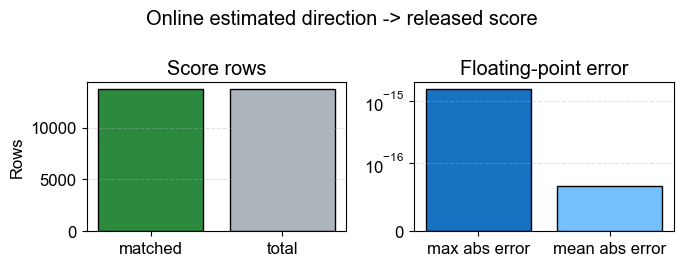

In [3]:
online_direction = published.copy()
assert len(online_direction) == 13671
online_direction["score_from_online_estimated_direction"] = projection_rate_score(
    online_direction["phone_rel_elevation"],
    online_direction["phone_rel_azimuth"],
    online_direction["elevation"],
    online_direction["earth_azimuth"],
)
online_direction["score_abs_error"] = (online_direction["score_from_online_estimated_direction"] - online_direction["score"]).abs()
online_direction["score_match"] = online_direction["score_abs_error"] <= SCORE_TOLERANCE

score_reproduction_summary = pd.DataFrame([
    {
        "check": "online estimated direction -> released score",
        "rows": len(online_direction),
        "matches": int(online_direction["score_match"].sum()),
        "match_rate": online_direction["score_match"].mean(),
        "max_abs_error": online_direction["score_abs_error"].max(),
        "mean_abs_error": online_direction["score_abs_error"].mean(),
    }
])

display(score_reproduction_summary)
fig = charts.plot_score_reproduction_check(score_reproduction_summary)
plt.show()
plt.close(fig)

assert online_direction["score_match"].all(), "Score must match when online estimated direction is fixed."


## 2. Recompute Estimated Direction from RSSI

This step starts from released RSSI, antenna layout, drone telemetry, and the measured beam pattern. The code below calls `algorithm/direction_replay.py`, which implements the configured `a_BcRxB` beam-pattern convolution replay with the released replay parameters:

- missing-RSSI noise floor: `-127 dBm`
- RSSI normalization: `z-score-nonzero`
- missing-RSSI padding: disabled
- non-zero RSSI smoothing: disabled
- search domain: positive elevation only

The notebook does not use the released estimated direction or released score columns in this step.


In [4]:
replay_context = direction_replay.build_replay_context(
    BEAM_PATTERN_SHEET_TSV,
    DEFAULT_LAYOUT_YAML,
    LAYOUT_20250709_YAML,
    normalization=RSSI_NORMALIZATION,
    noise_floor_dbm=REPLAY_NOISE_FLOOR_DBM,
    positive_elevation_only=POSITIVE_ELEVATION_ONLY,
)

replay_config = pd.DataFrame([
    {"setting": "configured replay path", "value": "a_BcRxB beam-pattern convolution"},
    {"setting": "RSSI normalization", "value": RSSI_NORMALIZATION},
    {"setting": "missing-RSSI noise floor", "value": f"{REPLAY_NOISE_FLOOR_DBM} dBm"},
    {"setting": "missing-RSSI padding", "value": "disabled"},
    {"setting": "non-zero RSSI smoothing", "value": "disabled"},
    {"setting": "positive-elevation search", "value": POSITIVE_ELEVATION_ONLY},
    {"setting": "beam-pattern calibration RSSI", "value": str(BEAM_PATTERN_SHEET_TSV.relative_to(ROOT))},
    {"setting": "replay helper", "value": "algorithm/direction_replay.py"},
    {"setting": "reference operators", "value": "algorithm/module/evaluation.py bp_form_cyclic_matrix, conv2d_fft, cross_correlation_2d_fft"},
    {"setting": "write recomputed CSV", "value": WRITE_RECOMPUTED_CSV},
])
display(replay_config)

recompute_limit = MAX_ROWS if RUN_FULL_RECOMPUTE else 200
estimated_direction_replay = direction_replay.recompute_estimated_direction(
    replay_input,
    replay_context,
    collection_labels=collection_labels,
    max_rows=recompute_limit,
    progress_every=500,
    rssi_columns=RSSI_COLUMNS,
)
print(f"Recomputed estimated direction rows: {len(estimated_direction_replay):,}")

direction_preview = estimated_direction_replay.join(replay_input[["device_name", "scene"]], how="left")
display(direction_preview[[
    "trial_id", "scene", "device_name",
    "recomputed_azimuth", "recomputed_elevation", "recompute_time_s",
]].head(10))


,setting,value
0,configured replay path,a_BcRxB beam-pattern convolution
1,RSSI normalization,z-score-nonzero
2,missing-RSSI noise floor,-127 dBm
3,missing-RSSI padding,disabled
4,non-zero RSSI smoothing,disabled
5,positive-elevation search,True
6,beam-pattern calibration RSSI,algorithm/data/case5-3d/sheet.tsv
7,replay helper,algorithm/direction_replay.py
8,reference operators,algorithm/module/evaluation.py bp_form_cyclic_...
9,write recomputed CSV,False


[   500/13671 ]   62.3 rows/s
[  1000/13671 ]   55.7 rows/s
[  1500/13671 ]   54.0 rows/s
[  2000/13671 ]   56.2 rows/s
[  2500/13671 ]   58.1 rows/s
[  3000/13671 ]   58.8 rows/s
[  3500/13671 ]   60.0 rows/s
[  4000/13671 ]   59.3 rows/s
[  4500/13671 ]   62.1 rows/s
[  5000/13671 ]   64.4 rows/s
[  5500/13671 ]   62.2 rows/s
[  6000/13671 ]   62.6 rows/s
[  6500/13671 ]   61.7 rows/s
[  7000/13671 ]   61.5 rows/s
[  7500/13671 ]   61.5 rows/s
[  8000/13671 ]   62.4 rows/s
[  8500/13671 ]   62.8 rows/s
[  9000/13671 ]   61.9 rows/s
[  9500/13671 ]   62.2 rows/s
[ 10000/13671 ]   62.0 rows/s
[ 10500/13671 ]   61.0 rows/s
[ 11000/13671 ]   60.9 rows/s
[ 11500/13671 ]   61.4 rows/s
[ 12000/13671 ]   60.5 rows/s
[ 12500/13671 ]   61.2 rows/s
[ 13000/13671 ]   61.0 rows/s
[ 13500/13671 ]   59.8 rows/s
[ 13671/13671 ]   59.9 rows/s
Recomputed estimated direction rows: 13,671


,trial_id,scene,device_name,recomputed_azimuth,recomputed_elevation,recompute_time_s
source_index,,,,,,
0,trial_01,Scene-P,IPAD,0,28,0.014412
1,trial_01,Scene-P,IP15,1,30,0.012326
2,trial_01,Scene-P,IP15,0,30,0.012484
3,trial_01,Scene-P,IPAD,359,28,0.011629
4,trial_01,Scene-P,IP15,1,30,0.011199
5,trial_01,Scene-P,IP15,1,30,0.012029
6,trial_01,Scene-P,IP15,0,30,0.011711
7,trial_01,Scene-P,IP15,1,30,0.012088
8,trial_01,Scene-P,IP15,1,30,0.011350


## 3. Score from Recomputed Estimated Direction

`algorithm/metric.py::earth_azimuth_from_body` converts the recomputed body-frame azimuth to earth-frame azimuth using drone yaw:

```text
earth_azimuth = (-azimuth + yaw) % 360
```

`algorithm/metric.py::projection_rate_score` is the package-local score helper used by this notebook. Keeping the score computation there avoids repeating the metric formula inside the notebook while preserving exact agreement with the released score values.


In [5]:
recomputed = replay_input.loc[estimated_direction_replay.index].copy()
recomputed["trial_id"] = recomputed["collection_id"].astype(str).map(collection_labels)
recomputed["azimuth"] = estimated_direction_replay["recomputed_azimuth"].astype(float)
recomputed["elevation"] = estimated_direction_replay["recomputed_elevation"].astype(float)
# algorithm/metric.py::earth_azimuth_from_body converts body-frame direction to earth-frame direction.
recomputed["earth_azimuth"] = earth_azimuth_from_body(recomputed["azimuth"], recomputed["yaw"])
# algorithm/metric.py::projection_rate_score is the package-local released-score helper.
recomputed["score"] = projection_rate_score(
    recomputed["phone_rel_elevation"],
    recomputed["phone_rel_azimuth"],
    recomputed["elevation"],
    recomputed["earth_azimuth"],
)

display(recomputed[[
    "trial_id", "device_name", "yaw",
    "phone_rel_azimuth", "phone_rel_elevation",
    "azimuth", "elevation", "earth_azimuth", "score",
]].head(10))


,trial_id,device_name,yaw,phone_rel_azimuth,phone_rel_elevation,azimuth,elevation,earth_azimuth,score
source_index,,,,,,,,,
0,trial_01,IPAD,-159.478605,202.539066,15.586256,0.0,28.0,200.521395,0.976093
1,trial_01,IP15,-159.698102,201.916068,20.360554,1.0,30.0,199.301898,0.985036
2,trial_01,IP15,-159.790986,201.972266,20.510210,0.0,30.0,200.209014,0.985931
3,trial_01,IPAD,-159.477922,202.605520,15.773105,359.0,28.0,201.522078,0.977165
4,trial_01,IP15,-159.620628,202.008067,20.451206,1.0,30.0,199.379372,0.985291
5,trial_01,IP15,-159.623839,201.999557,20.444951,1.0,30.0,199.376161,0.985276
6,trial_01,IP15,-160.194816,202.315374,20.922359,0.0,30.0,199.805184,0.986699
7,trial_01,IP15,-160.091687,202.442873,22.277019,1.0,30.0,198.908313,0.989405
8,trial_01,IP15,-160.515053,202.448501,23.210911,1.0,30.0,198.484947,0.991084


## 4. What Changes Under the Current Replay Path

The comparison below keeps the released manuscript score as the reference. A recomputed row can be unchanged, improved, or decreased depending on whether the configured RSSI replay estimates the same direction as the original online run. This section reports the observed deltas directly.


**Row-level score changes**

,rows,unchanged,improved,decreased
0,13671,7665,3463,2543


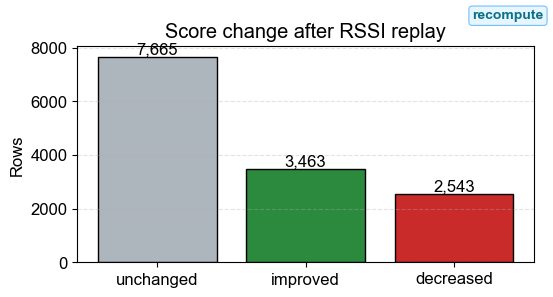

**Overall score distribution**

,metric,released score,recompute score,change
0,valid rows,13671.000000,13671.000000,0.000000
1,mean projection rate,0.839675,0.863897,0.024221
2,median projection rate,0.948845,0.956363,0.007518
3,20th percentile projection rate,0.823419,0.867343,0.043924
4,fraction projection rate >= 0.95,0.494916,0.547144,0.052227


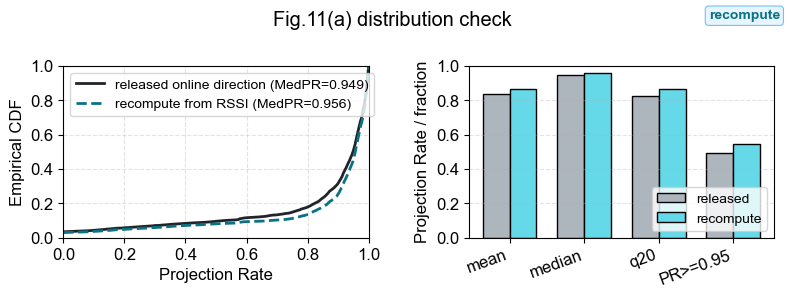

**Why released and recomputed scores can differ**

,estimated direction,rows,released_mean,recompute_mean,mean_delta,unchanged,improved,decreased
0,changed by RSSI replay,6101,0.795926,0.850201,5.427493e-02,95,3463,2543
1,same as online record,7570,0.874935,0.874935,1.912020e-18,7570,0,0


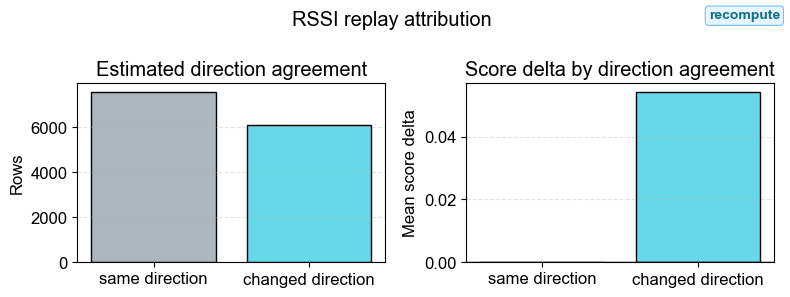

In [6]:
released_reference = published.loc[recomputed.index, ["azimuth", "elevation", "earth_azimuth", "score"]].copy()
comparison = recomputed[["trial_id", "collection_id", "scene", "device_name", "azimuth", "elevation", "earth_azimuth", "score"]].copy()
comparison = comparison.rename(columns={
    "azimuth": "recomputed_azimuth",
    "elevation": "recomputed_elevation",
    "earth_azimuth": "recomputed_earth_azimuth",
    "score": "recomputed_score",
})
comparison = comparison.join(released_reference.add_prefix("released_"))

valid = comparison[["released_azimuth", "released_elevation", "released_earth_azimuth", "released_score"]].notna().all(axis=1)
comparison = comparison[valid].copy()

comparison["azimuth_diff"] = ((comparison["recomputed_azimuth"] - comparison["released_azimuth"] + 180) % 360) - 180
comparison["elevation_diff"] = comparison["recomputed_elevation"] - comparison["released_elevation"]
comparison["max_angle_abs_error_deg"] = np.maximum(comparison["azimuth_diff"].abs(), comparison["elevation_diff"].abs())
comparison["estimated_direction_exact"] = comparison["max_angle_abs_error_deg"] <= ANGLE_TOLERANCE_DEG
comparison["score_delta"] = comparison["recomputed_score"] - comparison["released_score"]
comparison["score_abs_delta"] = comparison["score_delta"].abs()
comparison["score_relation"] = np.select(
    [comparison["score_delta"] > SCORE_TOLERANCE, comparison["score_delta"] < -SCORE_TOLERANCE],
    ["improved", "decreased"],
    default="unchanged",
)

score_change_summary = pd.DataFrame([
    {
        "rows": len(comparison),
        "unchanged": int((comparison["score_relation"] == "unchanged").sum()),
        "improved": int((comparison["score_relation"] == "improved").sum()),
        "decreased": int((comparison["score_relation"] == "decreased").sum()),
    }
])

score_distribution_summary = pd.DataFrame([
    {"metric": "valid rows", "released score": len(comparison), "recompute score": len(comparison), "change": 0.0},
    {"metric": "mean projection rate", "released score": comparison["released_score"].mean(), "recompute score": comparison["recomputed_score"].mean(), "change": comparison["score_delta"].mean()},
    {"metric": "median projection rate", "released score": comparison["released_score"].median(), "recompute score": comparison["recomputed_score"].median(), "change": comparison["recomputed_score"].median() - comparison["released_score"].median()},
    {"metric": "20th percentile projection rate", "released score": comparison["released_score"].quantile(0.20), "recompute score": comparison["recomputed_score"].quantile(0.20), "change": comparison["recomputed_score"].quantile(0.20) - comparison["released_score"].quantile(0.20)},
    {"metric": "fraction projection rate >= 0.95", "released score": (comparison["released_score"] >= 0.95).mean(), "recompute score": (comparison["recomputed_score"] >= 0.95).mean(), "change": (comparison["recomputed_score"] >= 0.95).mean() - (comparison["released_score"] >= 0.95).mean()},
])

direction_agreement_summary = comparison.groupby("estimated_direction_exact").agg(
    rows=("score_delta", "size"),
    released_mean=("released_score", "mean"),
    recompute_mean=("recomputed_score", "mean"),
    mean_delta=("score_delta", "mean"),
    unchanged=("score_relation", lambda s: int((s == "unchanged").sum())),
    improved=("score_relation", lambda s: int((s == "improved").sum())),
    decreased=("score_relation", lambda s: int((s == "decreased").sum())),
).reset_index()
direction_agreement_summary["estimated direction"] = np.where(
    direction_agreement_summary["estimated_direction_exact"],
    "same as online record",
    "changed by RSSI replay",
)
direction_agreement_summary = direction_agreement_summary[[
    "estimated direction", "rows", "released_mean", "recompute_mean", "mean_delta", "unchanged", "improved", "decreased"
]]

display(Markdown("**Row-level score changes**"))
display(score_change_summary)
fig = charts.plot_score_relation_counts(score_change_summary)
plt.show()
plt.close(fig)

display(Markdown("**Overall score distribution**"))
display(score_distribution_summary)
fig = charts.plot_score_distribution_comparison(comparison)
plt.show()
plt.close(fig)

display(Markdown("**Why released and recomputed scores can differ**"))
display(direction_agreement_summary)
fig = charts.plot_direction_replay_attribution(comparison)
plt.show()
plt.close(fig)

same_direction_rows = comparison[comparison["estimated_direction_exact"]]
assert (same_direction_rows["score_abs_delta"] <= SCORE_TOLERANCE).all(), "Rows with the same estimated direction should have identical scores."


## Takeaway

The Wi2SAR paper score path is fully reproduced from the online estimated direction recorded during flight trials. The RSSI replay path calls `algorithm/direction_replay.py` with the replay parameters listed above, then computes score with the package-local metric helper. It is included to show the full RSSI-to-score chain while keeping the notebook focused on evidence rather than helper implementations.


In [7]:
if WRITE_RECOMPUTED_CSV:
    raise RuntimeError("This notebook keeps recomputed results in memory and does not write CSV files by default.")

valid_rows = len(comparison)
same_direction_rows = int(comparison["estimated_direction_exact"].sum())
changed_direction_rows = valid_rows - same_direction_rows
unchanged_rows = int((comparison["score_relation"] == "unchanged").sum())
improved_rows = int((comparison["score_relation"] == "improved").sum())
decreased_rows = int((comparison["score_relation"] == "decreased").sum())
released_mean = comparison["released_score"].mean()
recomputed_mean = comparison["recomputed_score"].mean()
released_median = comparison["released_score"].median()
recomputed_median = comparison["recomputed_score"].median()
released_q20 = comparison["released_score"].quantile(0.20)
recomputed_q20 = comparison["recomputed_score"].quantile(0.20)
released_frac_095 = (comparison["released_score"] >= 0.95).mean()
recomputed_frac_095 = (comparison["recomputed_score"] >= 0.95).mean()

print(f"Released score reproduction: {int(score_reproduction_summary['matches'].iloc[0]):,} / {int(score_reproduction_summary['rows'].iloc[0]):,} valid rows match.")
print(f"RSSI replay keeps {unchanged_rows:,} rows unchanged, improves {improved_rows:,} rows, and decreases {decreased_rows:,} rows.")
print(f"Estimated direction is unchanged for {same_direction_rows:,} / {valid_rows:,} rows and changed for {changed_direction_rows:,} rows.")
print(f"Mean projection rate: {released_mean:.4f} -> {recomputed_mean:.4f} (change {recomputed_mean - released_mean:+.4f}).")
print(f"Median projection rate: {released_median:.4f} -> {recomputed_median:.4f} (change {recomputed_median - released_median:+.4f}).")
print(f"20th percentile projection rate: {released_q20:.4f} -> {recomputed_q20:.4f} (change {recomputed_q20 - released_q20:+.4f}).")
print(f"Fraction with projection rate >= 0.95: {released_frac_095:.2%} -> {recomputed_frac_095:.2%} (change {recomputed_frac_095 - released_frac_095:+.2%}).")
print("The paper reports the score computed from the original online estimated direction recorded during flight trials.")


Released score reproduction: 13,671 / 13,671 valid rows match.
RSSI replay keeps 7,665 rows unchanged, improves 3,463 rows, and decreases 2,543 rows.
Estimated direction is unchanged for 7,570 / 13,671 rows and changed for 6,101 rows.
Mean projection rate: 0.8397 -> 0.8639 (change +0.0242).
Median projection rate: 0.9488 -> 0.9564 (change +0.0075).
20th percentile projection rate: 0.8234 -> 0.8673 (change +0.0439).
Fraction with projection rate >= 0.95: 49.49% -> 54.71% (change +5.22%).
The paper reports the score computed from the original online estimated direction recorded during flight trials.
